# 16.4.2 路径误差、分布统计与风险

## 学习目标与先修知识

用重复轨迹（trajectory）比较解析矩、Monte Carlo 误差和约束违反。

先修：16.4.1 布朗增量；均值、方差（variance）和标准误（standard error）。

## 具体问题

相对参考水平的随机偏差平均接近零，却有少数轨迹越过安全界。仅报告平均性能是否足够？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
a=.7;sigma=.3;T=2.;print("解析终点均值与方差：",np.exp(-a*T),sigma*sigma*(1-np.exp(-2*a*T))/(2*a))

解析终点均值与方差： 0.2465969639416065 0.06037649597409313


## 模型假设

X 仍表示可正可负的稳态偏差，不是非负物质总量。固定种子只保证可复核，本节对每条轨迹独立抽增量。约束代理为终点 $X_T>0.7$，仅是人工阈值事件（event）；有限重复的频率不是硬安全保证。将解析连续矩与 EM 统计分开比较。

## 数学解释与推导

线性随机恢复（OU）的均值 $E[X_T]=x_0e^{-aT}$，方差 $\sigma^2(1-e^{-2aT})/(2a)$（$a>0$）。$R$ 条独立轨迹的样本均值标准误约为样本标准差（standard deviation）除以 $\sqrt R$；有限样本的越界比例还受二项抽样波动影响。路径配对误差、分布（distribution）矩差和风险频率分别回答不同问题。若反馈（feedback）改变 $a$，解析矩也应改用实际闭环参数（parameter）。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def em_path(x0,a,sigma,h,increments):
    state=float(x0);path=[state]
    for dw in increments:
        state=state-a*h*state+sigma*dw
        path.append(float(state))
    return path


def merge_brownian(increments,block):
    return [float(sum(increments[i:i+block]))
            for i in range(0,len(increments),block)]


def ou_moments(x0,a,sigma,time):
    mean=x0*math.exp(-a*time)
    variance=sigma*sigma*time if a==0 else sigma*sigma*(-math.expm1(-2*a*time))/(2*a)
    return [float(mean),float(variance)]

## 对照实验

固定步长生成 400 条独立路径，将终点分布与连续解析均值对照，同时计算超过 0.7 U 的比例。

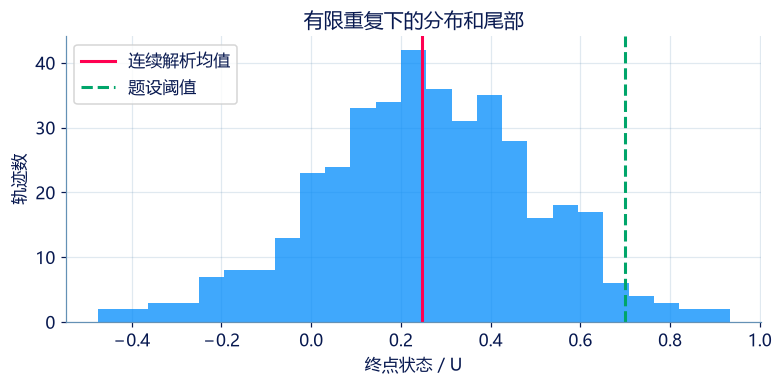

样本均值/标准误、样本方差、越界频率： 0.2555056669085216 0.01223682975984191 0.059896001028541035 0.0275
连续解析矩： 0.2465969639416065 0.06037649597409313


In [4]:
rng=np.random.default_rng(163);R=400;h=.02;N=100;end=[]
for _ in range(R):end.append(em_path(1.,.7,.3,h,np.sqrt(h)*rng.normal(size=N))[-1])
end=np.asarray(end);mean,var=ou_moments(1.,.7,.3,2.)
fig,ax=plt.subplots(figsize=(7,3.4));ax.hist(end,bins=25,color=BLUE,alpha=.75);ax.axvline(mean,color=PINK,label="连续解析均值");ax.axvline(.7,color=GREEN,ls="--",label="题设阈值");ax.set(xlabel="终点状态 / U",ylabel="轨迹数",title="有限重复下的分布和尾部");ax.legend();plt.show()
print("样本均值/标准误、样本方差、越界频率：",end.mean(),end.std(ddof=1)/np.sqrt(R),end.var(ddof=1),np.mean(end>.7));print("连续解析矩：",mean,var)

## 结果解释

样本矩与解析矩的差包含 Monte Carlo 波动和 Euler 离散偏差。越界频率必须连同重复数和阈值报告，不能由平均状态（state）推断零风险。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
assert len(end)==R and np.isfinite(end).all()
assert abs(end.mean()-mean)<5*end.std(ddof=1)/np.sqrt(R)+.01
assert 0<=np.mean(end>.7)<=1
print("解析均值与重复统计的容许差核验通过。")

解析均值与重复统计的容许差核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：均值和尾部

终点平均值低于安全阈值，能否宣称零违约风险？

- **A.** 能，平均值代表每条路径。
- **B.** 能，只要画了直方图。
- **C.** 不能；要报告阈值、重复数和越界频率。
- **D.** 只看一次最好轨迹（trajectory）即可。

[作答：均值和尾部](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-mean-risk)

### 第 2 题 · 单项选择题：强误差与弱统计量

同路径状态（state）差和独立重复的均值差各回答什么？

- **A.** 两者都是完全相同的观测（observation）噪声。
- **B.** 均值差就是每条路径误差。
- **C.** 只需前者，不用统计误差。
- **D.** 前者比较配对路径，后者比较分布（distribution）统计。

[作答：强误差与弱统计量](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-strong-weak)

### 第 3 题 · Python 计算题：OU 终点的解析矩

计算已声明 OU 模型（model）给定时刻的解析均值和方差（variance）。

**函数与代码模板**

```python
def solve(
    x0: float,
    a: float,
    sigma: float,
    time: float,
) -> tuple[float, float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 确定初态。 | U |
| `a` | `float` | 恢复率。 | 1/T |
| `sigma` | `float` | 噪声幅度。 | U/√T |
| `time` | `float` | 目标时刻。 | T |

**返回值**

按以下顺序返回元组：(mean, variance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 终点期望（expectation）。 | U |
| `variance` | `float` | 终点方差。 | U² |

**计算规则**

均值=x0*exp(-a*time)；a>0 时方差=sigma²*(1-exp(-2a*time))/(2a)，a=0 时为 sigma²*time。

**约束与边界**

- a≥0、sigma≥0、time≥0；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 确定初态。 | 1 | U |
| a | 恢复率。 | 0 | 1/T |
| sigma | 噪声幅度。 | 2 | U/√T |
| time | 目标时刻。 | 0.5 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.0
a = 0.0
sigma = 2.0
time = 0.5

result = solve(x0, a, sigma, time)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean | 终点期望（expectation）。 | 1 | U |
| variance | 终点方差。 | 2 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, 2.0)
```

**样例解释**

首例无恢复项，均值保持1，方差为 σ²t=2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：OU 终点的解析矩](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-ou-moments)

### 第 4 题 · Python 计算题：指定路径的随机终点

在给定增量下计算整条 OU 离散路径，供配对试算。

**函数与代码模板**

```python
def solve(
    x0: float,
    a: float,
    sigma: float,
    h: float,
    increments: list[float],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 初态。 | U |
| `a` | `float` | 恢复率。 | 1/T |
| `sigma` | `float` | 噪声幅度。 | U/√T |
| `h` | `float` | 步长。 | T |
| `increments` | `list[float]` | 已固定布朗增量。 | √T |

**返回值**

直接返回 states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 含初态的状态（state）路径。 | U |

**计算规则**

按给定布朗增量逐步计算 x_next=x-a*h*x+sigma*dw；不在函数内重新抽样。

**约束与边界**

- a≥0、sigma≥0、h>0；增量长度≤100且所有输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 初态。 | 0 | U |
| a | 恢复率。 | 0 | 1/T |
| sigma | 噪声幅度。 | 1 | U/√T |
| h | 步长。 | 0.1 | T |
| increments | 已固定布朗增量。 | [0.2, -0.1] | √T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 0.0
a = 0.0
sigma = 1.0
h = 0.1
increments = [0.2, -0.1]

result = solve(x0, a, sigma, h, increments)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 含初态的状态（state）路径。 | [0.0, 0.2, 0.1] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.2, 0.1]
```

**样例解释**

首例没有确定性恢复，状态依次为0、0.2、0.1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：指定路径的随机终点](http://127.0.0.1:8000/chapters/16-04-%E9%9A%8F%E6%9C%BA%E5%8A%A8%E5%8A%9B%E5%AD%A6%E4%B8%8E%E6%8E%A7%E5%88%B6/practice/?question=p16-paired-ou)

**进一步阅读**

[Higham](https://epubs.siam.org/doi/10.1137/S0036144500378302)区分随机路径与弱统计量。